# Linear Regression

## Description
- Linear regression is a statistical method used to find the relationship between a dependent variable and one or more independent variables by fitting a straight line to the data. Line is based on the minimum squared vertical distances, not the absolute or direct distances.
    - Dependent variable (Y): The main outcome or value you want to predict. (These are the effect of the inputs like in crop: kg, market prices)
    - Independent variable (X): The predictor or explanatory variable used to do the predicting. (These are the cause that can influence the Y: like demand, pH, light source)

# Visual
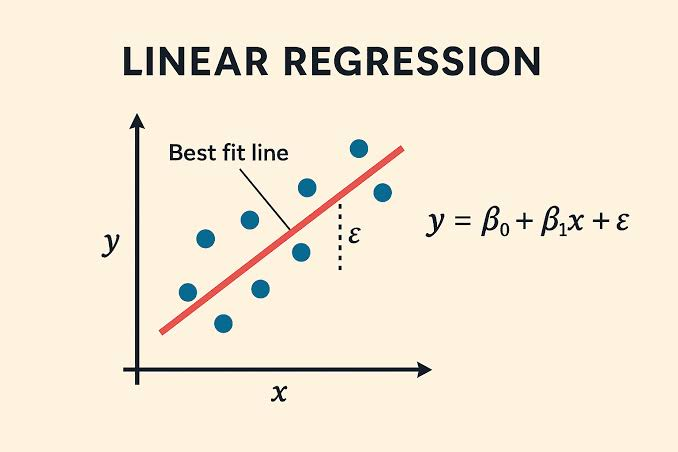

## How the line fitted?
- Vertical distance: The distance is measured vertically from the actual target value (the real data point) straight down or up to the predicted value on the line.
- Squared values: Each vertical distance (called a residual) is squared. This eliminates negative numbers and penalizes larger errors more heavily.
- Least Squares: The algorithm calculates the line that makes the Sum of Squared Residuals (SSR) as small as possible. This approach is called the Ordinary Least Squares (OLS) method.

# Formulas

### Slope ($b$)
$$b = \frac{n\sum(XY) - \sum X \sum Y}{n\sum(X^2) - (\sum X)^2}$$

### Intercept ($a$)
$$a = \frac{\sum Y - b\sum X}{n}$$

## Diabetes Prediction
- Diabetes dataset from the scikit-learn library

In [2]:
from sklearn import datasets

In [3]:
diabetes = datasets.load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

# EDA

In [4]:
diabetes.DESCR

'.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total cholesterol / HDL\n    - s5      ltg, possibly log of serum triglycerides level\n    - s6      glu, blood sugar level\n\nNote: Each of thes

In [5]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [6]:
X = diabetes.data
Y = diabetes.target
X, Y

(array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59.

In [7]:
X.shape, Y.shape

((442, 10), (442,))

In [8]:
len(diabetes.feature_names)

10

In [9]:
X, Y = datasets.load_diabetes(return_X_y=True)
X.shape, Y.shape

((442, 10), (442,))

# Training - Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [11]:
X_train.shape, X_test.shape

((353, 10), (89, 10))

In [12]:
Y_train.shape, Y_test.shape

((353,), (89,))

# Model Creation

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Prediction

In [15]:
Y_pred = model.predict(X_test)
Y_pred

array([ 53.82315444,  61.56283936, 115.70598642, 156.75220684,
       195.19316683, 125.75112732, 201.06394144, 124.79248348,
       111.16648194, 232.97976251, 190.93874869, 175.8596534 ,
       168.4444584 ,  99.10018812, 198.8233059 , 218.33143566,
       131.16294794, 226.24917167,  66.26298041, 117.31305564,
       142.49736095,  77.84201721, 198.37188012, 257.91195572,
       199.8097939 , 189.89591909, 131.62217431, 203.52094456,
        64.60940057,  93.82927202, 150.70847962, 161.1389508 ,
       136.40238962,  51.52477178, 108.25714796, 116.31118704,
       223.65795604, 280.92126426, 117.89508488, 263.36922734,
        91.15714424,  98.4911968 , 230.6805135 , 140.85322304,
       205.66075305, 180.79848788, 140.58865356, 171.51474152,
       200.01011837, 134.14382217, 120.69896153,  54.5303815 ,
       253.11968461,  56.32538587, 195.23813866, 178.13873968,
       162.1475841 , 151.7042779 , 191.61500671, 105.66269042,
       151.02103155,  97.48315247, 150.58693184, 201.24

# Plots

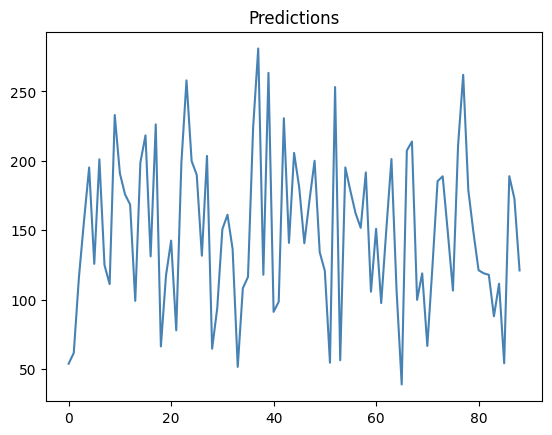

In [16]:
import matplotlib.pyplot as plt
plt.plot(Y_pred, color='steelblue')
plt.title('Predictions')
plt.show()

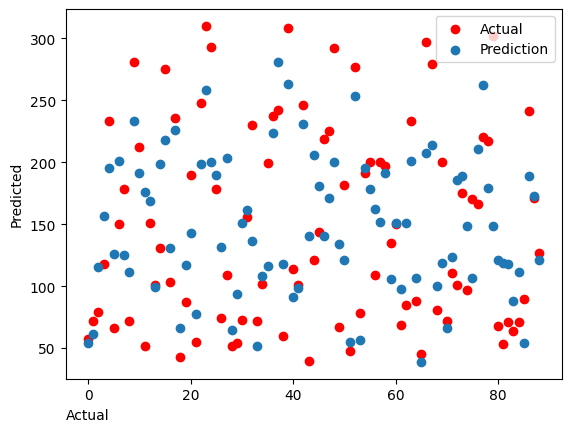

In [18]:
plt.scatter(range(len(Y_test)), Y_test, color='red', label='Actual')
plt.scatter(range(len(Y_pred)), Y_pred,  label='Prediction')
plt.xlabel('Actual', loc='left')
plt.ylabel('Predicted')
plt.legend()
plt.show()

# Evaluation

In [ ]:
print('Coefficients: ', model.coef_)
print('Intercept: ', model.intercept_)
print('Mean Squared Error (MSE): %.2f' % mean_squared_error(Y_test, Y_pred))
print('Coefficient of determination (R^2): %.2f' % r2_score(Y_test, Y_pred))

Coefficients:  [  -3.25803134 -226.23036857  526.43101068  314.46641165 -835.71782265
  461.1049312   137.30139686  215.51349993  733.66129689   80.04461817]
Intercept:  152.28117812166948
Mean Squared Error (MSE): 2702.97
Coefficient of determination (R^2): 0.57


# Metric & Equations

- Coefficients are your multiplier to the inputs for each feature
$$
\begin{aligned}
Y = 152.2812 
&- 3.2580(\text{age}) - 226.2304(\text{sex}) + 526.4310(\text{bmi}) \\
&+ 314.4664(\text{bp}) - 835.7178(\text{s1}) + 461.1049(\text{s2}) \\
&+ 137.3014(\text{s3}) + 215.5135(\text{s4}) + 733.6613(\text{s5}) \\
&+ 80.0446(\text{s6})
\end{aligned}
$$
- Intercept is the base line of the Y, this also where the it starting point where the regression line crosses the vertical Y-axis on a graph. Also called as the constant or the bias term 
- Mean Squared Error (MSE): MSE measures the average of the squared errors between your model's predictions and the actual target values. $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
    - ($y_i$): Target value: The actual value from your real-world data.
    - ($\hat{y}_i$): Predicted value: The value calculated by your model line.
    - ($n$): Sample size: The total number of data points used.
    - Interpretation: A lower average error means your model predictions are closer to reality.
- Coefficient of Determination($R^2$) - \(R^{2}\) measures the proportion of variance in the dependent variable that is predictable from the independent variables.
    $$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$

    $$\text{Where: } SS_{\text{res}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \quad \text{and} \quad SS_{\text{tot}} = \sum_{i=1}^{n} (y_i - \bar{y})^2$$

    - ($SS_{\text{res}}$): (Residual Sum of Squares): The sum of squared errors from your regression line.
    - ($SS_{\text{tot}}$): (Total Sum of Squares): The sum of squared differences from the baseline average line ($\bar{y}$).
    - Interpretation
        - ($R^2 = 1$): Perfect model; explains 100% of the data variance.
        - ($R^2 = 0$): Explains none of the variance (performs no better than predicting the average).




In [20]:
'%f' % r2_score(Y_test, Y_pred) # 6 max

'0.571534'